**<font color = black size=6>植物病理学分类</font>**

**<font color = blue size=4>第一部分:引入所需库</font>**

In [4]:
import os
import torch
from torch.utils.data import DataLoader
from dataset import PlantPathologyDataset, get_transforms, Mosaic
from timm import create_model
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score, average_precision_score
from tqdm import tqdm
import numpy as np
import json
import pandas as pd
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image

**<font color = blue size=4>第二部分:数据处理</font>**

**<font color = purple size=2>建立数据处理的class</font>**

In [7]:
# 定义最终6个基本类别
BASE_CLASSES = ["scab", "healthy", "frog_eye_leaf_spot", "rust", "complex", "powdery_mildew"]

def map_to_six_classes(label_str):
    # 将原始标签字符串（可能包含多个类别）分解
    sub_labels = label_str.strip().split()
    final_labels = set()
    for sl in sub_labels:
        # 如果子标签本身属于6类之一
        if sl in BASE_CLASSES:
            final_labels.add(sl)
        else:
            # 如果子标签不是6类之一，但可能是复合标签，将其与6类匹配
            for base in BASE_CLASSES:
                if base in sl:
                    final_labels.add(base)
                    break
    return list(final_labels)

class PlantDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, mlb=None, is_test=False):
        """
        Args:
            csv_file (str): 标签文件路径
            img_dir (str): 图像文件夹路径
            transform: 图像预处理/增强方法
            mlb (MultiLabelBinarizer): 用于标签二值化的编码器，可从训练集中传递到验证/测试集保证一致性
            is_test (bool): 标记是否为测试集
        """
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

        if not is_test:
            # 将原始标签映射到6类标签//one-hot编码
            self.data['mapped_labels'] = self.data['labels'].apply(map_to_six_classes)

            # 如果没有传入 mlb，则在训练集上fit一个新的
            if mlb is None:
                self.mlb = MultiLabelBinarizer()
                self.mlb.fit(self.data['mapped_labels'].tolist())
            else:
                self.mlb = mlb

            self.encoded_labels = self.mlb.transform(self.data['mapped_labels'].tolist())
        else:
            # 测试集如果有标签文件并需要映射标签，请与训练集同样处理
            # 如果测试集不需要标签（仅生成预测结果），则无需处理
            pass

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]['images']
        img_path = os.path.join(self.img_dir, img_name)
        image = np.array(Image.open(img_path).convert("RGB"))
            
        if self.transform:
            image = self.transform(image)

        if self.is_test:
            # 测试集无标签，返回图像和文件名
            return image, img_name
        else:
            # 训练或验证集返回图像和标签
            labels = self.encoded_labels[idx]
            labels = torch.FloatTensor(labels)
            return image, labels

def get_transforms(train=True):
    if train:
        transforms_list = [
            transforms.ToPILImage(), # 将图像数据转换为 PIL 图像格式
            transforms.Resize((224, 224)), # 将图像的大小调整模型期望的 (224, 224)
            transforms.RandomHorizontalFlip(p=0.75), # 以 50% 的概率对图像进行水平翻转
            transforms.RandomVerticalFlip(p=0.75), # 以指定概率进行随机垂直翻转 
            transforms.RandomRotation(degrees=90), # 以最大90度的范围对图像进行随机旋转
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.75, 1.333)), # 随机裁剪图像，并将其大小调整为指定的大小
            transforms.AugMix(severity=3, mixture_width=3, alpha=0.2), # 应用 AugMix 数据增强，包括混合、扭曲和增强
            transforms.AutoAugment(), # 根据预定义的策略自动进行增强
            transforms.RandAugment(), # 根据预定义的策略自动进行增强
            transforms.ToTensor(),  # 将图像数据转换为 PyTorch 张量
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # 对图像进行标准化，减去均值并除以标准差
            ]
        return transforms.Compose(transforms_list)
    else:
        return transforms.Compose([
            transforms.ToPILImage(), 
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ])


**<font color = purple size=2>进行一些可视化</font>**

Index 0 in binary vector represents class 'complex'
Index 1 in binary vector represents class 'frog_eye_leaf_spot'
Index 2 in binary vector represents class 'healthy'
Index 3 in binary vector represents class 'powdery_mildew'
Index 4 in binary vector represents class 'rust'
Index 5 in binary vector represents class 'scab'


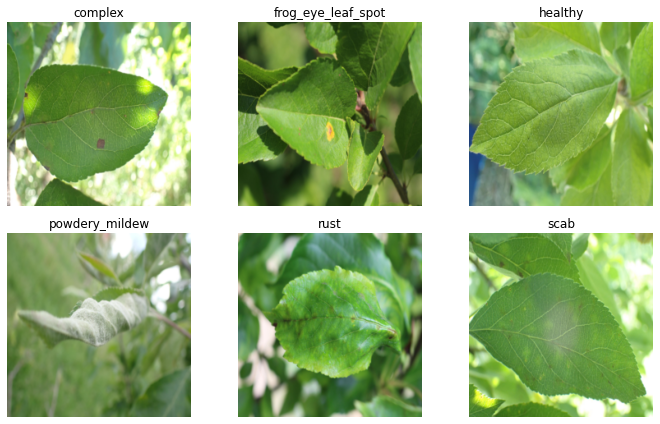

In [8]:
# 每个类别选一代表图像进行展示

train_csv = pd.read_csv("data/train/train_label.csv")
train_img_dir = 'data/train/images'
train_dataset = PlantPathologyDataset(csv_file=train_csv, img_dir=train_img_dir, transform=get_transforms(train=True), is_test=False)

labels = dataset.label_list  
image_names = dataset.image_names  

# 定义一个字典来保存每个类别的索引
class_indices = {
    'complex': [],
    'frog_eye_leaf_spot': [],
    'healthy': [],
    'powdery_mildew': [],
    'rust': [],
    'scab': []
}

# 填充class_indices字典，添加各类别的索引
for idx, label in enumerate(dataset.label_list):
    if label[0] == 1:
        class_indices['complex'].append(idx)
    elif label[1] == 1:
        class_indices['frog_eye_leaf_spot'].append(idx)
    elif label[2] == 1:
        class_indices['healthy'].append(idx)
    elif label[3] == 1:
        class_indices['powdery_mildew'].append(idx)
    elif label[4] == 1:
        class_indices['rust'].append(idx)
    elif label[5] == 1:
        class_indices['scab'].append(idx)

# 用于展示图像的函数
def show_images(images, titles, rows, cols):
    fig, axs = plt.subplots(rows, cols, figsize=(10, 6))
    for i in range(rows):
        for j in range(cols):
            axs[i, j].imshow(images[i * cols + j])
            axs[i, j].set_title(f"{titles[i * cols + j]}", fontsize=12)
            axs[i, j].axis('off')
    plt.tight_layout()
    plt.show()

# 为每个类别选择随机图像
random_images = []
titles = []

for class_name, indices in class_indices.items():
    random_index = random.choice(indices)
    img, _ = dataset[random_index]
    random_images.append(img.permute(1, 2, 0))
    titles.append(class_name)
    
# 在网格中展示随机图像
show_images(random_images, titles, 2, 3)

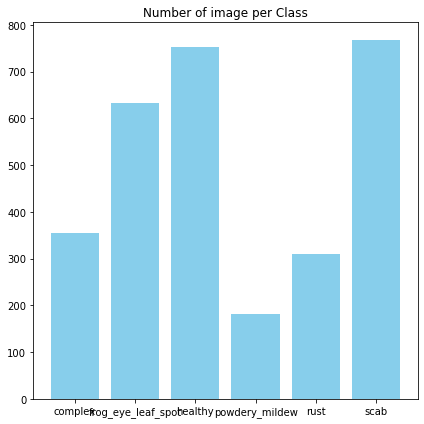

In [10]:
# 统计每个类别的图像数量

class_counts = {class_name: len(indices) for class_name, indices in class_indices.items()}
# 绘制条形图
plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title('Number of image per Class')
plt.tight_layout()
plt.show()

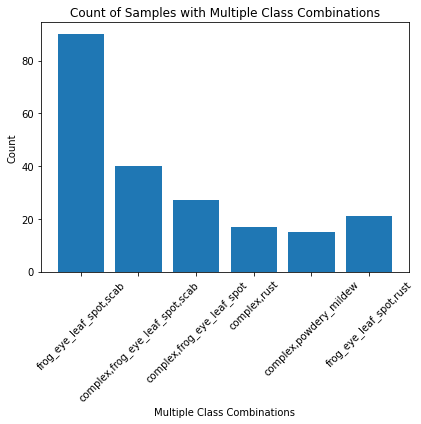

In [11]:
# 寻找具有多个标签的图片数量

# 类别标签
class_labels = [
    'complex',
    'frog_eye_leaf_spot',
    'healthy',
    'powdery_mildew',
    'rust',
    'scab'
]

# 创建一个字典来记录拥有相同多类别组合的样本数量
multilabel_combinations = defaultdict(int)

for idx, labels in enumerate(dataset.label_list):
    # 找出多类别样本
    if sum(labels) > 1:
        # 将多类别标签转换为对应的文字组合，作为组合的键
        label_combination = ','.join([class_labels[i] for i, label in enumerate(labels) if label == 1])
        multilabel_combinations[label_combination] += 1

# 创建条形图的横轴和纵轴数据
x_labels = list(multilabel_combinations.keys())
y_counts = list(multilabel_combinations.values())

# 绘制条形图
plt.figure(figsize=(10, 6))
plt.bar(x_labels, y_counts)
plt.xlabel('Multiple Class Combinations')
plt.ylabel('Count')
plt.title('Count of Samples with Multiple Class Combinations')
plt.xticks(rotation=45)  # 旋转横坐标标签，使其更易读
plt.tight_layout()
plt.show()


**<font color = blue size=4>第三部分:训练模型</font>**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 数据路径
train_csv = 'data/train/train_labels.csv'
val_csv = 'data/val/val_labels.csv'
train_img_dir = 'data/train/images'
val_img_dir = 'data/val/images'

# 实例化数据集（训练集和验证集）
# 创建 Mosaic 对象
#mosaic = Mosaic(train_img_dir, mosaic_size=(1, 2), target_size=(256, 256))
# 生成并保存多个 Mosaic 图像
#for _ in range(50):  # 生成50张 Mosaic 图像
    #mosaic.save_mosaic_image()
train_dataset = PlantPathologyDataset(csv_file=train_csv, img_dir=train_img_dir, transform=get_transforms(train=True), is_test=False)
val_dataset = PlantPathologyDataset(csv_file=val_csv, img_dir=val_img_dir, transform=get_transforms(train=False), is_test=False, mlb=train_dataset.mlb)

# 保存 MultiLabelBinarizer 对象
with open('mlb.pkl', 'wb') as f:
    pickle.dump(train_dataset.mlb, f)

if __name__ == '__main__':
    # 创建 DataLoader
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

    # 定义模型
    #model = timm.create_model('vit_base_patch16_224', pretrained=True)
    model = create_model('vit_base_patch16_224', pretrained=False)  # 不从Hugging Face下载
    state_dict = torch.load('pytorch_model.bin', weights_only=True)
    model.load_state_dict(state_dict, strict=False)
    num_classes = len(train_dataset.mlb.classes_)
    model.head = nn.Sequential(
        nn.Linear(model.head.in_features, num_classes),
        nn.Sigmoid()
    )
    model = model.to(device)

    # 定义损失函数和优化器
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)

    # 训练配置
    num_epochs = 20
    best_f1 = 0.0
    best_model_path = 'best_model.pth'

    # 记录指标
    metrics = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "val_map": []
    }

    # 训练循环
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # 验证阶段
        model.eval()
        val_loss = 0.0
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                all_labels.append(labels.cpu().numpy())
                all_preds.append(outputs.cpu().numpy())

        val_epoch_loss = val_loss / len(val_loader.dataset)
        all_labels = np.vstack(all_labels)
        all_preds = np.vstack(all_preds)

        # 计算验证指标
        val_acc = accuracy_score(all_labels, all_preds > 0.5)
        val_f1 = f1_score(all_labels, all_preds > 0.5, average='macro')
        val_map = average_precision_score(all_labels, all_preds, average='macro')

        # 打印指标
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {epoch_loss:.4f}")
        print(f"Val Loss: {val_epoch_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f} | mAP: {val_map:.4f}\n")

        # 记录指标
        metrics["train_loss"].append(epoch_loss)
        metrics["val_loss"].append(val_epoch_loss)
        metrics["val_acc"].append(val_acc)
        metrics["val_f1"].append(val_f1)
        metrics["val_map"].append(val_map)

        # 调整学习率
        scheduler.step(val_f1)

        # 保存最佳模型
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_model_path)
            print(f"模型参数已更新: {best_model_path}")

    # 保存指标数据到 JSON 文件
    with open("metrics.json", "w") as f:
        json.dump(metrics, f)
    print("训练完成，指标已保存到 metrics.json")
    print(f"最佳 F1-score: {best_f1:.4f}")

**<font color = purple size=2>可视化loss和acc</font>**

In [ ]:
# 1. 绘制训练集指标曲线
def plot_train_metrics(metrics_file):
    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    epochs = range(1, len(metrics["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # 绘制损失曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, metrics["train_loss"], label="Train Loss")
    plt.plot(epochs, metrics["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()

    # 绘制精确度、召回率、F1 和 mAP 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, metrics["val_acc"], label="Validation Accuracy")
    plt.plot(epochs, metrics["val_f1"], label="Validation F1")
    plt.plot(epochs, metrics["val_map"], label="Validation mAP")
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.title("Validation Metrics")
    plt.legend()

    plt.tight_layout()
    plt.savefig('train_metrics_plot.png')  # 设置保存路径
    plt.show()

**<font color = blue size=4>第四部分:预测及结果可视化</font>**

In [1]:
# 定义设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 数据路径
test_csv = 'data/test/test_labels.csv'  # 测试集包含标签信息
test_img_dir = 'data/test/images'
mlb_path = 'mlb.pkl'                    # 多标签编码器路径
best_model_path = 'best_model.pth'      # 最佳模型路径
metrics_file = 'metrics.json'           # 训练过程指标文件

# 加载 mlb 对象（MultiLabelBinarizer）
with open('mlb.pkl', 'rb') as f:
    mlb = pickle.load(f)

# 加载模型函数
def load_model(model_path, num_classes):
    model = timm.create_model('vit_base_patch16_224', pretrained=False)
    model.head = nn.Sequential(
        nn.Linear(model.head.in_features, num_classes),
        nn.Sigmoid()  # 多标签分类使用 Sigmoid
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

# 计算性能指标函数
def evaluate(model, data_loader, mlb):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating"):
            images = images.to(device)
            outputs = model(images)

            # 将预测的概率转换为二值标签（阈值为0.5）
            preds = (outputs.cpu().numpy() > 0.5).astype(int)

            all_preds.append(preds)
            all_labels.append(labels.numpy())

    # 转换为NumPy数组
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # 计算各类指标
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    map_score = average_precision_score(all_labels, all_preds, average='macro')

    return acc, f1, map_score

if __name__ == '__main__':
    # 创建测试集
    test_dataset = PlantPathologyDataset(
        csv_file=test_csv,
        img_dir=test_img_dir,
        transform=get_transforms(train=False),  # 使用验证集同样的预处理
        is_test=False,  # 此时加载真实标签
        mlb=mlb  # 保证标签编码一致
    )

    # 创建 DataLoader
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)  # num_workers=0 避免多进程问题

    # 加载模型
    best_model_path = 'best_model.pth'
    print(f"加载模型: {best_model_path}")
    model = load_model(best_model_path, num_classes=len(mlb.classes_))

    # 评估模型
    print("开始评估测试集...")
    test_acc, test_f1, test_map = evaluate(model, test_loader, mlb)

    # 打印结果
    print(f"\n测试集性能指标:")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"F1-score (Macro): {test_f1:.4f}")
    print(f"mAP (Mean Average Precision): {test_map:.4f}")

#结果可视化

#绘制ROC曲线和PR曲线
def plot_roc_pr_curves(model, test_loader, mlb):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs).cpu().numpy()  # Sigmoid输出，得到概率
            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # 绘制ROC曲线
    plt.figure(figsize=(12, 6))
    for i in range(all_preds.shape[1]):  # 针对每个类别绘制ROC曲线
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {mlb.classes_[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.savefig('roc_curve.png')
    plt.show()

    # 绘制PR曲线
    plt.figure(figsize=(12, 6))
    for i in range(all_preds.shape[1]):  # 针对每个类别绘制PR曲线
        precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
        average_precision = average_precision_score(all_labels[:, i], all_preds[:, i])
        plt.plot(recall, precision, label=f'Class {mlb.classes_[i]} (AP = {average_precision:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall (PR) Curve')
    plt.legend(loc="lower left")
    plt.savefig('pr_curve.png')
    plt.show()

#绘制每个类别的精确度、召回率和F1变化
def plot_class_metrics(model, test_loader, mlb):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # 计算每个类别的精确度、召回率和F1分数
    precision = precision_score(all_labels, all_preds, average=None)
    recall = recall_score(all_labels, all_preds, average=None)
    f1 = f1_score(all_labels, all_preds, average=None)

    # 绘制精确度、召回率和F1的变化
    plt.figure(figsize=(12, 6))
    x = range(len(mlb.classes_))
    plt.subplot(1, 3, 1)
    plt.bar(x, precision)
    plt.xticks(x, mlb.classes_, rotation=90)
    plt.ylabel('Precision')
    plt.title('Classwise Precision')

    plt.subplot(1, 3, 2)
    plt.bar(x, recall)
    plt.xticks(x, mlb.classes_, rotation=90)
    plt.ylabel('Recall')
    plt.title('Classwise Recall')

    plt.subplot(1, 3, 3)
    plt.bar(x, f1)
    plt.xticks(x, mlb.classes_, rotation=90)
    plt.ylabel('F1 Score')
    plt.title('Classwise F1 Score')

    plt.tight_layout()
    plt.savefig('class_metrics.png')
    plt.show()

#计算并输出测试集的全局性能指标
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # 计算每个类的精度、召回率和F1分数
    precision = precision_score(all_labels, all_preds, average=None)
    recall = recall_score(all_labels, all_preds, average=None)
    f1 = f1_score(all_labels, all_preds, average=None)

    # 输出测试集的性能指标
    print("Test Precision:", precision)
    print("Test Recall:", recall)
    print("Test F1 Score:", f1)

    # 计算微平均（micro average）和宏平均（macro average）
    precision_micro = precision_score(all_labels, all_preds, average='micro')
    recall_micro = recall_score(all_labels, all_preds, average='micro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')

    precision_macro = precision_score(all_labels, all_preds, average='macro')
    recall_macro = recall_score(all_labels, all_preds, average='macro')
    f1_macro = f1_score(all_labels, all_preds, average='macro')

    print(f"Micro Average Precision: {precision_micro:.4f}, Recall: {recall_micro:.4f}, F1: {f1_micro:.4f}")
    print(f"Macro Average Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1: {f1_macro:.4f}")

if __name__ == '__main__':
    # 1. 绘制训练集指标曲线
    print("正在绘制训练指标曲线...")
    plot_train_metrics(metrics_file)

    # 2. 加载模型并进行评估
    print("正在进行模型评估...")
    model = timm.create_model('vit_base_patch16_224', pretrained=False)
    model.head = nn.Sequential(nn.Linear(model.head.in_features, 6), nn.Sigmoid())
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model = model.to(device)

    with open(mlb_path, 'rb') as f:
        mlb = pickle.load(f)

    test_dataset = PlantPathologyDataset(
        csv_file=test_csv,
        img_dir=test_img_dir,
        transform=get_transforms(train=False),
        is_test=False,
        mlb=mlb
    )
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

    # 3. 绘制ROC曲线和PR曲线
    print("正在绘制ROC曲线和PR曲线...")
    plot_roc_pr_curves(model, test_loader, mlb)

    # 4. 绘制类别指标
    print("正在绘制类别精确度、召回率和F1...")
    plot_class_metrics(model, test_loader, mlb)

    # 5. 评估全局性能指标
    print("正在评估模型在测试集上的全局性能指标...")
    evaluate_model(model, test_loader)

NameError: name 'torch' is not defined